<a href="https://colab.research.google.com/github/emm-gl/machine-learning-portfolio/blob/main/03_DeepLearning/LSTM_VanishGradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reto 3
 Emmanuel Gonzalez Calitl

# Vanishing Gradient

## Objetivo
Este notebook estudia experimentalmente el problema del **vanishing gradient** en redes recurrentes (RNNs/LSTMs).  
Usaremos la serie de tiempo de consumo eléctrico del [UCI Electricity Dataset](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014) y entrenaremos el mismo modelo LSTM **4 veces**, variando únicamente la **inicialización de pesos**.

### ¿Qué es el vanishing gradient?
Durante el entrenamiento de una red neuronal, el algoritmo de backpropagation calcula gradientes que fluyen *hacia atrás* en el tiempo. En redes recurrentes con secuencias largas, estos gradientes pueden multiplicarse repetidamente por valores pequeños, haciendo que se vuelvan **casi cero** antes de llegar a las primeras capas. Esto se llama **vanishing gradient** y provoca que el modelo deje de aprender patrones de largo plazo.

### ¿Cómo lo mediremos?
- **Función de costo (MSE)** por época → ¿converge el modelo?
- **Norma del gradiente** por época → ¿se desvanece o explota el gradiente?

### Configuraciones a comparar
| # | Nombre | kernel_initializer | recurrent_initializer |
|---|--------|-------------------|----------------------|
| 1 | glorot_uniform | glorot_uniform | orthogonal |
| 2 | he_normal | he_normal | he_normal |
| 3 | orthogonal | orthogonal | orthogonal |
| 4 | random_normal | RandomNormal(std=0.2) | RandomNormal(std=0.2) |

### Data

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import tensorflow.keras.backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

from pathlib import Path
import math

Link de data original:
[Data](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014)

In [2]:
# Instalamos ucimlrepo para descarga automática del dataset
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo', '-q'])
print('ucimlrepo instalado correctamente.')


ucimlrepo instalado correctamente.


In [3]:
# Descargamos el dataset UCI Electricity (ID=321) y lo guardamos localmente.
# La primera vez puede tardar ~1-2 minutos (~130 MB comprimido).
from pathlib import Path
import urllib.request, zipfile

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
path = data_dir / 'LD2011_2014.txt'

if not path.exists():
    zip_url = 'https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip'
    zip_path = data_dir / 'electricity.zip'
    print('Descargando dataset (~130 MB)...')
    urllib.request.urlretrieve(zip_url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(data_dir)
    zip_path.unlink()
    print('Dataset listo en:', path)
else:
    print('Dataset ya existe en:', path)


Descargando dataset (~130 MB)...
Dataset listo en: data/LD2011_2014.txt


In [4]:
df_15min = pd.read_csv(path, sep=';', parse_dates=[0], index_col=0, decimal=',', dtype=np.float64)
df_15min.head(3)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_15min.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


In [6]:
df_15min.shape

(140256, 370)

## Preprocesado

In [7]:
df_15min = df_15min.sort_index() ##Order in chronological order, a prerequisite for time series analysis
df_15min = df_15min[~df_15min.index.duplicated(keep="first")] ##identifies and removes any duplicate entries in the DataFrame's index.

In [8]:
expected_freq = pd.infer_freq(df_15min.index[:8]) or "15T"
print("Inferred 15-min frequency (approx):", expected_freq)

Inferred 15-min frequency (approx): 15min


In [9]:
full_idx = pd.date_range(df_15min.index.min(), df_15min.index.max(), freq="15T")
if len(full_idx) != len(df_15min.index):
    print("Reindexing to full 15-min grid and forward-filling missing values...")
    df_15min = df_15min.reindex(full_idx).ffill()

/tmp/ipython-input-507045246.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(df_15min.index.min(), df_15min.index.max(), freq="15T")


In [10]:
df_daily = df_15min.resample("1D").sum()

print("Daily shape:", df_daily.shape)
df_daily.head(3)

Daily shape: (1462, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df_daily

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2011-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-28,227.157360,2131.578947,151.172893,14327.235772,6776.829268,20122.023810,429.621255,25255.892256,5118.881119,4794.623656,...,28815.132049,3272100.0,220721.518987,257477.272727,8169.491525,552.369807,45914.837577,4405.676127,66135.630499,1.553189e+06
2014-12-29,248.730964,2212.660028,160.729800,14067.073171,7198.780488,22824.404762,550.593556,30286.195286,6697.552448,6337.634409,...,28825.124911,3109100.0,206852.320675,269090.909091,8438.070404,1153.891164,53928.884987,12914.858097,73882.697947,1.806486e+06
2014-12-30,232.233503,2205.547653,165.073849,14290.650407,7189.024390,23880.952381,586.772188,30909.090909,6487.762238,6489.247312,...,28488.222698,2904300.0,204126.582278,263613.636364,10615.384615,892.334699,56334.503951,15996.661102,73950.146628,1.867568e+06
2014-12-31,229.695431,2273.115220,166.811468,14006.097561,7023.170732,23511.904762,690.785755,28700.336700,6211.538462,5034.408602,...,26970.735189,2748800.0,162556.962025,215886.363636,7415.906128,530.134582,50259.877085,13245.409015,70416.422287,1.365892e+06


### Definición de ventana para predicción:

Tomando 15 días de entrenamiento para predecir 7 días en el futuro:

In [12]:
W = 15   # lookback window
H = 7    # forecast horizon

def make_windows(arr, window=W, horizon=H):
    X, y = [], []
    for i in range(len(arr) - window - horizon + 1):
        X.append(arr[i:i+window])
        y.append(arr[i+window:i+window+horizon].ravel())
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y


In [13]:
X = np.empty(shape=(0,W))
y = np.empty(shape=(0,H))

n_cols = len(df_daily.columns)

for i in range(n_cols):
    arr = df_daily.iloc[:,i].values
    X_, y_ = make_windows(arr, W, H)
    X = np.concatenate([X, X_], axis=0)
    y = np.concatenate([y, y_], axis=0)

In [14]:
X[400]

array([ 356.59899902,  453.04568481,  737.30963135,  667.51269531,
        350.2538147 ,  286.80203247,  258.88323975,  239.84771729,
        314.7208252 ,  953.04571533, 1507.61425781, 1515.22839355,
       1512.69030762, 1365.48217773, 1441.62438965])

In [15]:
y[400]

array([1378.17260742, 1506.34521484, 1425.12695312, 1380.71069336,
       1439.08630371, 1661.16748047, 1454.31469727])

In [16]:
X.shape

(533170, 15)

Tenemos 533,170 renglones, cada renglon tiene 15 días de consumo,

In [17]:
y.shape

(533170, 7)

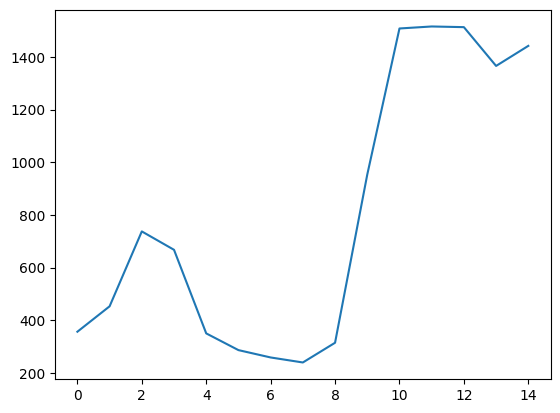

In [18]:
series = X[400]
plt.plot(series)
plt.show()

In [19]:
permutation = np.random.permutation(len(X))

X = X[permutation]
y = y[permutation]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled.shape

(319902, 15)

In [23]:
scaler2 = StandardScaler()
y_train_scaled = scaler2.fit_transform(y_train)
y_val_scaled = scaler2.transform(y_val)
y_test_scaled = scaler2.transform(y_test)

## Modelo

### Para una celda LSTM

**Forget gate**

$
F_t = \sigma(W_f x_t + U_f H_{t-1} + b_f)
$

**Input gate**

$
I_t = \sigma(W_i x_t + U_i H_{t-1} + b_i)
$

**Candidate cell state**

$
\tilde{C}_t = \tanh(W_c x_t + U_c H_{t-1} + b_c)
$

**New cell state**

$
C_t = f_t \odot C_{t-1} + I_t \odot \tilde{C}_t
$

**Output gate**

$
O_t = \sigma(W_o x_t + U_o H_{t-1} + b_o)
$

**New hidden state**

$
H_t = O_t \odot \tanh(C_t)
$

Entonces la función de transición nos queda:

$
f_{\theta}(x_t, H_{t-1}, C_{t-1}) = (h_t, c_t)
$



![image](https://d2l.ai/_images/lstm-3.svg)

[Referencia](https://d2l.ai/chapter_recurrent-modern/lstm.html)

In [27]:
# Modelo LSTM parametrizado por inicializadores de pesos.
# kernel_initializer   → pesos de la transformación de entrada (W)
# recurrent_initializer → pesos de la conexión recurrente (U)
# Son estos pesos los que determinan si el gradiente se desvanece al inicio.

def build_model(window=W, horizon=H,
                kernel_init='glorot_uniform',
                recurrent_init='orthogonal'):
    inputs = tf.keras.Input(shape=(window, 1))
    x = layers.LSTM(128, return_sequences=True,
                    kernel_initializer=kernel_init,
                    recurrent_initializer=recurrent_init)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64,
                    kernel_initializer=kernel_init,
                    recurrent_initializer=recurrent_init)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(horizon)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

# Verificamos la arquitectura base
model = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,423 (454.78 KB)

 Trainable params: 116,423 (454.78 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [24]:
ckpt_dir = Path("checkpoints"); ckpt_dir.mkdir(exist_ok=True)
ckpt_path = str(ckpt_dir / "best.keras")

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_loss")
]

In [25]:
ckpt_path

'checkpoints/best.keras'

In [28]:
# Entrenamiento del modelo base (glorot_uniform / orthogonal)
history = model.fit(
    X_train_scaled[..., None], y_train_scaled,
    validation_data=(X_val_scaled[..., None], y_val_scaled),
    epochs=50,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.2828 - mae: 0.0592 - val_loss: 0.0337 - val_mae: 0.0185
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0380 - mae: 0.0393 - val_loss: 0.0267 - val_mae: 0.0191
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0274 - mae: 0.0373 - val_loss: 0.0169 - val_mae: 0.0164
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0272 - mae: 0.0349 - val_loss: 0.0179 - val_mae: 0.0279
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0279 - mae: 0.0333 - val_loss: 0.0175 - val_mae: 0.0146
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0237 - mae: 0.0310 - val_loss: 0.0177 - val_mae: 0.0154
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0235 - mae: 0.0299 - val_loss: 0.0157 - val_mae: 0.0225
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0232 - mae: 0.0285 - val_loss: 0.0157 - val_mae: 0.0130
Epoch 9/50
1250/1250 ━━━━━━━━━━━

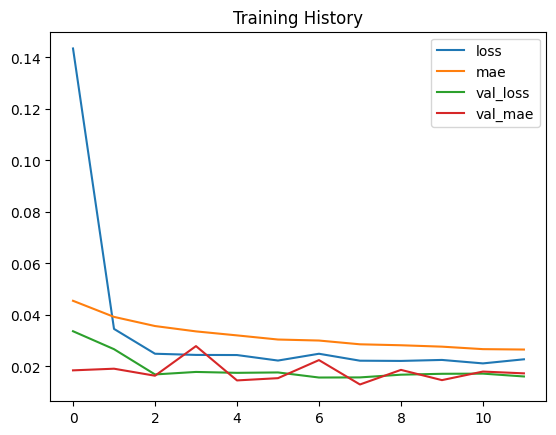

In [29]:
pd.DataFrame(history.history).plot(title="Training History")
plt.show()

---
## Experimento: Vanishing Gradient — 4 Configuraciones de Inicialización

Entrenamos el mismo modelo LSTM **4 veces** cambiando únicamente los inicializadores.
Por cada época registramos:
- **MSE** (función de costo): ¿converge el modelo?
- **Norma L2 del gradiente**: ¿se desvanece (→0) o explota (→∞)?

| # | Nombre | kernel_initializer | recurrent_initializer |
|---|--------|-------------------|----------------------|
| 1 | glorot_uniform | glorot_uniform | orthogonal |
| 2 | he_normal | he_normal | he_normal |
| 3 | orthogonal | orthogonal | orthogonal |
| 4 | random_normal | RandomNormal(std=0.2) | RandomNormal(std=0.2) |


In [30]:
# Callback personalizado para capturar la norma del gradiente por época.
# Al final de cada época, calcula los gradientes sobre un mini-batch fijo
# y registra la norma L2 global (raíz de la suma de cuadrados de todos los gradientes).

class GradientNormLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_batch, y_batch):
        super().__init__()
        # Mini-batch fijo de 256 muestras para calcular gradientes reproducibles
        self.X_batch = tf.constant(X_batch[:256], dtype=tf.float32)
        self.y_batch = tf.constant(y_batch[:256], dtype=tf.float32)
        self.grad_norms = []  # norma del gradiente por época

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            y_pred = self.model(self.X_batch, training=False)
            loss   = tf.reduce_mean(tf.square(y_pred - self.y_batch))
        grads = tape.gradient(loss, self.model.trainable_variables)
        # Norma global: sqrt( sum_i ||grad_i||^2 )
        norm = tf.sqrt(tf.reduce_sum([
            tf.reduce_sum(tf.square(g))
            for g in grads if g is not None
        ]))
        self.grad_norms.append(float(norm.numpy()))

print('GradientNormLogger definido.')


GradientNormLogger definido.


In [31]:
# Las 4 configuraciones a comparar (según la tabla del objetivo del notebook)
configs = [
    dict(name='glorot_uniform',
         kernel_init='glorot_uniform',
         recurrent_init='orthogonal'),
    dict(name='he_normal',
         kernel_init='he_normal',
         recurrent_init='he_normal'),
    dict(name='orthogonal',
         kernel_init='orthogonal',
         recurrent_init='orthogonal'),
    dict(name='random_normal',
         kernel_init=tf.keras.initializers.RandomNormal(stddev=0.2),
         recurrent_init=tf.keras.initializers.RandomNormal(stddev=0.2)),
]
print('Configuraciones:', [c['name'] for c in configs])


Configuraciones: ['glorot_uniform', 'he_normal', 'orthogonal', 'random_normal']


In [32]:
# Loop principal: entrenar las 4 configuraciones y guardar resultados.
# Usamos 20 épocas para un experimento rápido pero ilustrativo.
# Aumenta EPOCHS para un análisis más completo.

EPOCHS_EXP = 20
BATCH_EXP  = 256

# Reshape de datos: LSTM necesita (samples, timesteps, features)
Xtr_3d = X_train_scaled[..., np.newaxis]  # (N, 15, 1)
Xvl_3d = X_val_scaled[..., np.newaxis]

all_results = {}  # guardará mse_train, mse_val, grad_norms por config

for cfg in configs:
    cname = cfg['name']
    print('\n' + '='*55)
    print(f'  Config: {cname}')
    print('='*55)

    # Construir modelo con esta configuración de inicializadores
    m = build_model(kernel_init=cfg['kernel_init'],
                    recurrent_init=cfg['recurrent_init'])

    # Callback para registrar la norma del gradiente
    grad_logger = GradientNormLogger(Xtr_3d, y_train_scaled)

    cb_exp = [
        tf.keras.callbacks.EarlyStopping(
            patience=10, restore_best_weights=True, monitor='val_loss'),
        grad_logger
    ]

    hist = m.fit(
        Xtr_3d, y_train_scaled,
        validation_data=(Xvl_3d, y_val_scaled),
        epochs=EPOCHS_EXP,
        batch_size=BATCH_EXP,
        callbacks=cb_exp,
        verbose=1
    )

    all_results[cname] = {
        'mse_train' : hist.history['loss'],
        'mse_val'   : hist.history['val_loss'],
        'grad_norms': grad_logger.grad_norms,
        'model'     : m
    }

print('\n Todos los modelos entrenados.')



  Config: glorot_uniform
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.2626 - mae: 0.0584 - val_loss: 0.0361 - val_mae: 0.0213
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0351 - mae: 0.0384 - val_loss: 0.0216 - val_mae: 0.0238
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0296 - mae: 0.0378 - val_loss: 0.0193 - val_mae: 0.0153
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0250 - mae: 0.0359 - val_loss: 0.0178 - val_mae: 0.0207
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0254 - mae: 0.0335 - val_loss: 0.0173 - val_mae: 0.0177
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0217 - mae: 0.0306 - val_loss: 0.0158 - val_mae: 0.0172
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0220 - mae: 0.0291 - val_loss: 0.0195 - val_mae: 0.0159
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0234 - mae: 0.0296 - val_loss: 0.0168 - val_mae: 0.0182
Epoc

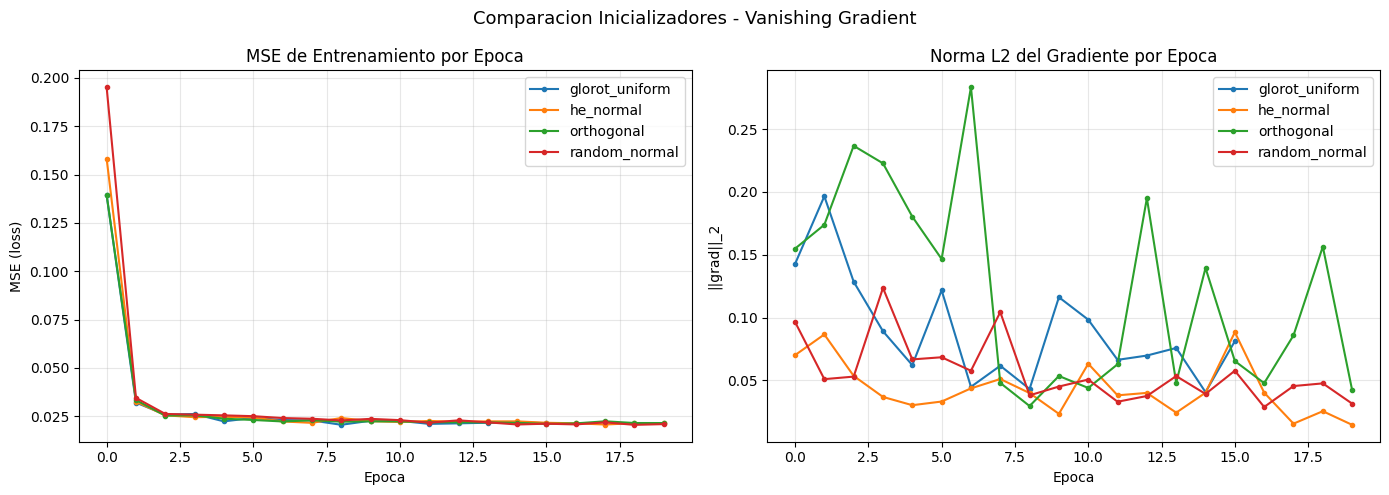

In [33]:
# Graficas comparativas: MSE por época y Norma del Gradiente por época

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in all_results.items():
    axes[0].plot(res['mse_train'], label=name, marker='o', markersize=3)

axes[0].set_title('MSE de Entrenamiento por Epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE (loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, res in all_results.items():
    axes[1].plot(res['grad_norms'], label=name, marker='o', markersize=3)

axes[1].set_title('Norma L2 del Gradiente por Epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('||grad||_2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacion Inicializadores - Vanishing Gradient', fontsize=13)
plt.tight_layout()
plt.savefig('vanishing_gradient_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


### Conclusiones:

* **Gráfica de MSE**: Todas las configuraciones convergen igual de rápido y llegan casi al mismo error final (~0.021). Esto es buena noticia porque significa que el inicializador no rompe el entrenamiento. La LSTM es suficientemente robusta (gracias a sus gates) para aprender bien sin importar cómo empezó.

* **Gráfica de la norma del gradiente**
  * *he_normal* (naranja) — gradientes pequeños y muy estables. El modelo aprende "en voz baja" pero consistente. No hay vanishing severo, solo señal tranquila.
  * glorot_uniform (azul) — gradientes moderados con algo de variación al inicio, luego se estabilizan. Es el comportamiento más "textbook correcto".
  * random_normal (rojo) — empieza alto (~0.10) y baja de manera irregular. Hay algo de inestabilidad al principio pero logra controlarse.
  * orthogonal (verde) — es el más ruidoso e irregular de todos. Sube hasta 0.28 en la época 6, luego baja, luego sube otra vez. Esto es inusual para orthogonal, que en teoría debería ser estable. Posiblemente hay interacción entre el inicializador orthogonal en ambas capas LSTM a la vez.






In [34]:
# Tabla resumen con métricas finales de cada configuración
# Permite comparar cuantitativamente qué inicializador converge mejor
# y cuál produce gradientes más saludables.

rows = []
for name, res in all_results.items():
    rows.append({
        'Inicializador'    : name,
        'MSE_Train_Final'  : round(res['mse_train'][-1], 6),
        'MSE_Val_Final'    : round(res['mse_val'][-1], 6),
        'GradNorm_Final'   : round(res['grad_norms'][-1], 6),
        'GradNorm_Min'     : round(min(res['grad_norms']), 6),
        'Epocas'           : len(res['mse_train'])
    })

summary_df = pd.DataFrame(rows).set_index('Inicializador')
print('=== Resumen del Experimento Vanishing Gradient ===')
summary_df


=== Resumen del Experimento Vanishing Gradient ===


,MSE_Train_Final,MSE_Val_Final,GradNorm_Final,GradNorm_Min,Epocas
Inicializador,,,,,
glorot_uniform,0.021394,0.016762,0.081215,0.040664,16
he_normal,0.021467,0.014938,0.014649,0.014649,20
orthogonal,0.021502,0.016192,0.042269,0.029609,20
random_normal,0.020948,0.015454,0.031512,0.028852,20


# Evaluación

In [35]:
y_pred_scaled = model.predict(X_test_scaled, verbose=0)

In [36]:
y_test_scaled.shape

(106634, 7)

In [37]:
# Back to original units (kW)
y_test_orig = scaler2.inverse_transform(y_test_scaled)
y_pred_orig = scaler2.inverse_transform(y_pred_scaled)

In [38]:
def mape(y_true, y_pred, eps=1e-6):
    denom = np.clip(np.abs(y_true), eps, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

def smape(y_true, y_pred, eps=1e-6):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.clip(denom, eps, None)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100.0


In [39]:
yt = y_test_orig.reshape(-1)
yp = y_pred_orig.reshape(-1)

In [40]:
metrics = {}
metrics["MAE"] = float(mean_absolute_error(yt, yp))
metrics["RMSE"] = float(math.sqrt(mean_squared_error(yt, yp)))
metrics["MAPE_%"] = float(mape(yt, yp))
metrics["sMAPE_%"] = float(smape(yt, yp))
metrics["R2"] = float(r2_score(yt, yp))

In [41]:
results_df = pd.DataFrame(metrics, index=["LSTM"]).T
results_df

,LSTM
MAE,6.250189e+03
RMSE,3.551150e+04
MAPE_%,7.416788e+10
sMAPE_%,6.255739e+01
R2,9.849244e-01


In [42]:
print(W, H)

15 7


In [43]:
len(X_train)

319902

In [48]:
sample_idx = 3500
past = X_test[sample_idx]
truth = y_test_orig[sample_idx]
preds = y_pred_orig[sample_idx]

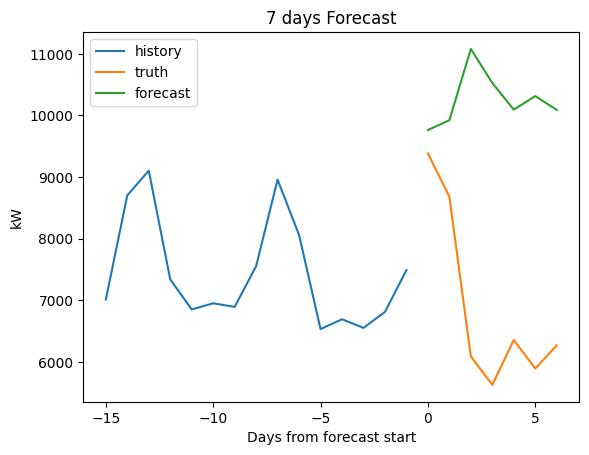

In [49]:
plt.figure()
plt.plot(range(-len(past), 0), past, label="history")
plt.plot(range(0, len(truth)), truth, label="truth")
plt.plot(range(0, len(preds)), preds, label="forecast")
plt.title(f"7 days Forecast")
plt.xlabel("Days from forecast start")
plt.ylabel("kW")
plt.legend()
plt.show()

In [46]:
sample_idx = 65000
past = X_test[sample_idx]
truth = y_test_orig[sample_idx]
preds = y_pred_orig[sample_idx]

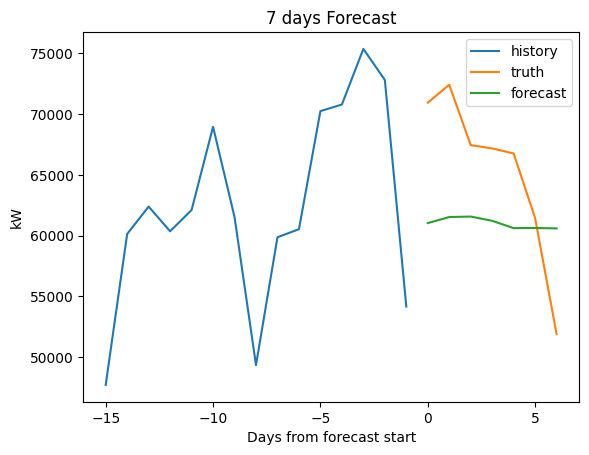

In [47]:
plt.figure()
plt.plot(range(-len(past), 0), past, label="history")
plt.plot(range(0, len(truth)), truth, label="truth")
plt.plot(range(0, len(preds)), preds, label="forecast")
plt.title(f"7 days Forecast")
plt.xlabel("Days from forecast start")
plt.ylabel("kW")
plt.legend()
plt.show()